Lea Frost \
CSCE 580 \
Code for Q3 on Quiz 1

Load in data

In [1]:
import pandas as pd

datafile = "./Redacted-Department _ CAD Reconciliation.csv"

# Read data from local file
data = pd.read_csv(datafile)
data.head()
type(data)

pandas.core.frame.DataFrame

#### a) Data issues

1. What is the range of data for the cases (dispatches) ? 

In [2]:
# Range of dispatch dates
data["DISPATCH CREATED DATE"] = pd.to_datetime(data["DISPATCH CREATED DATE"], errors="coerce", infer_datetime_format=True)
#print(dispatch_dates)

start = data["DISPATCH CREATED DATE"].min()
end = data["DISPATCH CREATED DATE"].max()

print("Range:", start, "to", end)

time_length = end - start

print("Length:", time_length)


<ipython-input-2-7a18ff69182b>:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data["DISPATCH CREATED DATE"] = pd.to_datetime(data["DISPATCH CREATED DATE"], errors="coerce", infer_datetime_format=True)
<ipython-input-2-7a18ff69182b>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["DISPATCH CREATED DATE"] = pd.to_datetime(data["DISPATCH CREATED DATE"], errors="coerce", infer_datetime_format=True)


Range: 2025-03-24 15:54:00 to 2025-08-31 23:03:00
Length: 160 days 07:09:00


2. What % of data is missing, by each column?

In [3]:
missing = data.isna().mean() * 100
print(missing)

XREF ID                   0.000000
DISPATCH UNIT             0.000000
DISPATCH CREATED DATE     0.000000
INCIDENT NUMBER           0.000000
1ST UNIT ON SCENE        19.454545
ALARM DATE TIME           1.409091
CALL COMPLETE             1.409091
SHIFT                     3.136364
dtype: float64


3. What data issues are there (e.g., different formats) and how we can resolve them

Issues:
- There are a decent number of missing values, especially in the 1st Unit on scene column. 
- For the dispatch unit column, there are different amounts of dispatch units
- The columns use different formats from eachother, e.g. dates vs unit vs shift letter
- Need to convert times to standardized times
- Units have different formats in the dispatch unit vs 1st unit on scene column (E171 vs E-171, LDR175 vs L-175)
- Some of the incident numbers have 00 instead of -

Solutions:
- For the 1st unit on scene column, the missing values will be left as NA to form its own category
- Dispatch units will have to be stored as a list
- Standardize the unit names by removing hyphens and choosing the shortest name
- Replace 00 with - 

4. Resolve data issues. Assign IDs. Pick a method for handling missing data and use consistently. Describe
your data cleaning strategy, as appropriate. Do remainder of the tasks with data resolved.

In [4]:
# Assign IDs as XREF ID
data = data.set_index("XREF ID")
print(data)

                   DISPATCH UNIT DISPATCH CREATED DATE INCIDENT NUMBER  \
XREF ID                                                                  
2025107105  BAT111, E171, LDR175   2025-03-24 15:54:00         25-1368   
2025107223                BAT111   2025-03-24 17:28:00         25-1369   
2025107415                  E171   2025-03-24 21:03:00         25-1370   
2025107411                  E171   2025-03-24 21:03:00         25-1371   
2025107384  BAT111, E171, LDR175   2025-03-24 21:43:00         25-1374   
...                          ...                   ...             ...   
2025326268                LDR175   2025-08-31 12:28:00         25-4052   
2025326380                LDR175   2025-08-31 14:18:00         25-4053   
2025326497    BAT111, E171, E172   2025-08-31 15:53:00         25-4054   
2025326555                  E171   2025-08-31 16:48:00         25-4055   
2025326922                LDR175   2025-08-31 23:03:00         25-4056   

           1ST UNIT ON SCENE ALARM DA

Standardize times (date created already done)

In [5]:
data["ALARM DATE TIME"] = pd.to_datetime(data["ALARM DATE TIME"], errors="coerce", infer_datetime_format=True)
data["CALL COMPLETE"] = pd.to_datetime(data["CALL COMPLETE"], errors="coerce", infer_datetime_format=True)

<ipython-input-5-6ad6cb41ab79>:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data["ALARM DATE TIME"] = pd.to_datetime(data["ALARM DATE TIME"], errors="coerce", infer_datetime_format=True)
<ipython-input-5-6ad6cb41ab79>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["ALARM DATE TIME"] = pd.to_datetime(data["ALARM DATE TIME"], errors="coerce", infer_datetime_format=True)
<ipython-input-5-6ad6cb41ab79>:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html.

Standardize unit names

In [6]:
# Split and strip dispatch unit column
data["DISPATCH UNIT"] = data["DISPATCH UNIT"].str.split(",").apply(
    lambda x: [u.strip() for u in x] if isinstance(x, list) else x
)
print(data["DISPATCH UNIT"])

XREF ID
2025107105    [BAT111, E171, LDR175]
2025107223                  [BAT111]
2025107415                    [E171]
2025107411                    [E171]
2025107384    [BAT111, E171, LDR175]
                       ...          
2025326268                  [LDR175]
2025326380                  [LDR175]
2025326497      [BAT111, E171, E172]
2025326555                    [E171]
2025326922                  [LDR175]
Name: DISPATCH UNIT, Length: 2200, dtype: object


In [7]:
# Get unique DISPATCH UNIT units

# Split units by splitting by commas, exploding, and stripping whitespace
units_dispatch = data["DISPATCH UNIT"].explode()

# print(units)

# Get list of all unique unit names from dispatch unit column
unique_units_dispatch = units_dispatch.unique()
print(unique_units_dispatch)

['BAT111' 'E171' 'LDR175' 'E172' 'C102' 'C108' 'C103' 'E173' 'B117' 'C107'
 'SRT117' 'E174' 'M105' 'C101' 'RG170']


In [8]:
# Get unique 1ST UNIT ON SCENE units

# Split units by splitting by commas, exploding, and stripping whitespace
units_1st = data["1ST UNIT ON SCENE"].str.split(",").explode().str.strip()

# print(units_1st)

# Get list of all unique unit names from dispatch unit column
unique_units_1st = units_1st.unique()
print(unique_units_1st)

['BC-111' 'E-171' nan 'L-175' 'E-172' 'C-102' 'C-103' 'C-108' 'C-107'
 'SRT-117' 'M-105']


In [9]:
# Figure out which names refer to the same unit

# BC-111->  BAT111
# E-171 ->  E171
# E-172 ->  E172
# L-175 ->  LDR175
# C-102 ->  C102
# C-103 ->  C103
# C-107 ->  C107
# C-108 ->  C108
# SRT-117   -> SRT177
# M-105 ->  M105

# Choose format for others
# RG170 ->  keep
# E173  ->  keep
# E174  ->  keep
# C101  ->  keep
# B117  ->  keep

unit_dict = {
    "BC-111": "BAT111",
    "E-171" : "E171",
    "E-172" : "E172",
    "L-175" : "L175",
    "LDR175": "L175",
    "C-102" : "C102",
    "C-103" : "C103",
    "C-107" : "C107",
    "C-108" : "C108",
    "SRT-117" : "SRT117",
    "M-105" : "M105"
}

# Replace nan with "Unknown"
data["DISPATCH UNIT"].fillna(value="Unknown")
data["1ST UNIT ON SCENE"].fillna(value="Unknown") # doesn't work?
data["1ST UNIT ON SCENE"] = data["1ST UNIT ON SCENE"].replace(float('nan'), 'Unknown')

# Replace dispatch units
data["DISPATCH UNIT"] = data["DISPATCH UNIT"].apply(
    lambda x: [unit_dict.get(u, u) for u in x] if isinstance(x, list) else x)

# Verify correctness
print(data["DISPATCH UNIT"].explode().unique())


# Replace 1st units
data["1ST UNIT ON SCENE"] = data["1ST UNIT ON SCENE"].apply(
    lambda x: [unit_dict.get(u, u) for u in x] if isinstance(x, list) else x
)
# Verify correctness
print(data["1ST UNIT ON SCENE"].explode().unique())


['BAT111' 'E171' 'L175' 'E172' 'C102' 'C108' 'C103' 'E173' 'B117' 'C107'
 'SRT117' 'E174' 'M105' 'C101' 'RG170']
['BC-111' 'E-171' 'Unknown' 'L-175' 'E-172' 'C-102' 'C-103' 'C-108'
 'C-107' 'SRT-117' 'M-105']


Standardize Incident numbers

In [10]:
# Replace 2500 with 25-
data["INCIDENT NUMBER"] = data["INCIDENT NUMBER"].str.replace(r"^2500", "25-", regex=True)

#### b) Exploratory data analysis

1. On an average, in how much time is a call (alarm) resolved from the time it is created to closed ?

In [11]:
data["DURATION"] = (data["CALL COMPLETE"] - data["ALARM DATE TIME"])
avg_resolve = (data["DURATION"]).mean()
print("Average time between alarm and marked complete")
print(avg_resolve)

Average time between alarm and marked complete
90 days 18:28:08.907330567


2. How many fire units, on an average, are usually sent for a fire alarm?

In [12]:
data["NUM_UNITS"] = data["DISPATCH UNIT"].apply(lambda x: len(x) if isinstance(x, list) else 1)
average_units = data["NUM_UNITS"].mean()
print("Average number of units sent:")
print(round(average_units, 3))

Average number of units sent:
1.441


3. Which shift is the busiest among A, B, C ?

In [13]:
shift_counts = data["SHIFT"].value_counts()
print("Shift counts:")
print(shift_counts)
print("\nBusiest shift:")
print("Shift", shift_counts.idxmax(), "with", shift_counts.max(), "occurences")

Shift counts:
SHIFT
A    735
C    719
B    677
Name: count, dtype: int64

Busiest shift:
Shift A with 735 occurences


4. Create a matrix of number of file alarms organized by the day of week (x_axis) and hour of the day (yaxis). It will also have totals for each row and column. See illustration below.

In [14]:
# Initialize dataframe
alarms = pd.DataFrame(columns=['HOUR', 'SUNDAY', 'MONDAY', 'TUESDAY', 'WEDNESDAY', 
                               'THURSDAY', 'FRIDAY', 'SATURDAY', 'TOTAL'])
alarms['HOUR'] = [f"{h:02d}:00" for h in range(24)]
alarms = alarms.fillna(0)
alarms = alarms.set_index('HOUR')

<ipython-input-14-ddda8fea5137>:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  alarms = alarms.fillna(0)


In [15]:
# match 
weekday_map = {
    0: "MONDAY",
    1: "TUESDAY",
    2: "WEDNESDAY",
    3: "THURSDAY",
    4: "FRIDAY",
    5: "SATURDAY",
    6: "SUNDAY"
}

# iterate through all cases, also calculate day, hour
for index, row in data.iterrows():
    alarm_time = row["ALARM DATE TIME"]
    if pd.isna(alarm_time): # If alarm missing, use dispatch date
        alarm_time = row["DISPATCH CREATED DATE"]

    hour = alarm_time.hour # get hour
    hour = f"{hour:02d}:00" # change to correct label
    day = alarm_time.weekday() # get weekday (int)
    day = weekday_map[day] # change to correct label
    alarms.at[hour, day] += 1
print(alarms)


       SUNDAY  MONDAY  TUESDAY  WEDNESDAY  THURSDAY  FRIDAY  SATURDAY  TOTAL
HOUR                                                                        
00:00       4       8        7          6         2       3         7      0
01:00      10      11       10          8         8       4         8      0
02:00      10       5        4          3         3       3         8      0
03:00       7       9        9          9         1      10         5      0
04:00       4       3        4          5         2       7         6      0
05:00       7       9        3          6         5       5         3      0
06:00       9       5        5          7         7      11         7      0
07:00      11      15       15          9        10      14         5      0
08:00      14      13       14         18        10       7         6      0
09:00      14      10       17         14        14      16        12      0
10:00      11      20       24         18        15      14        16      0

Calculate total and counts

In [16]:
days =  ["SUNDAY","MONDAY","TUESDAY","WEDNESDAY","THURSDAY","FRIDAY","SATURDAY"]

alarms["TOTAL"] = alarms[days].sum(axis=1) # calculate hour totals
totals = alarms[days + ["TOTAL"]].sum() # calculate day totals
alarms.loc["Count of Incidents"] = totals

print(alarms)

                    SUNDAY  MONDAY  TUESDAY  WEDNESDAY  THURSDAY  FRIDAY  \
HOUR                                                                       
00:00                    4       8        7          6         2       3   
01:00                   10      11       10          8         8       4   
02:00                   10       5        4          3         3       3   
03:00                    7       9        9          9         1      10   
04:00                    4       3        4          5         2       7   
05:00                    7       9        3          6         5       5   
06:00                    9       5        5          7         7      11   
07:00                   11      15       15          9        10      14   
08:00                   14      13       14         18        10       7   
09:00                   14      10       17         14        14      16   
10:00                   11      20       24         18        15      14   
11:00       

#### c) Unsupervised learning

1. Cluster the data based on any two methods in sci-kit and report on their cluster quality. Which method performs better ?

Create numeric features for clustering

In [31]:
# Hour
# If alarm NA, use dispatch
data["HOUR"] = data["ALARM DATE TIME"].dt.hour.fillna(data["DISPATCH CREATED DATE"].dt.hour)

# Day
# Use alarm by default, dispatch if NA
data["DAY"] = data["ALARM DATE TIME"].dt.weekday.fillna(data["DISPATCH CREATED DATE"].dt.weekday)
    
# Shift
# If NA, use value above
shift_map = {"A": 0, "B": 1, "C": 2}
data["SHIFT_CODE"] = data["SHIFT"].map(shift_map).fillna(method="ffill")

# Duration (min)
# For na, fill with median
duration = (data["DURATION"]).dt.total_seconds()
data["DURATION_MIN"] = duration.fillna(duration.median()) / 60

# Time between alarm and dispatch (minutes)
# For na, fill with median
alarm_dispatch = (data["DISPATCH CREATED DATE"] - data["ALARM DATE TIME"]).dt.total_seconds()
data["ALARM_DISPATCH_DURATION"] = alarm_dispatch.fillna(alarm_dispatch.median()) /60

print(data)


<ipython-input-31-525851f86922>:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["SHIFT_CODE"] = data["SHIFT"].map(shift_map).fillna(method="ffill")


                   DISPATCH UNIT DISPATCH CREATED DATE INCIDENT NUMBER  \
XREF ID                                                                  
2025107105  [BAT111, E171, L175]   2025-03-24 15:54:00         25-1368   
2025107223              [BAT111]   2025-03-24 17:28:00         25-1369   
2025107415                [E171]   2025-03-24 21:03:00         25-1370   
2025107411                [E171]   2025-03-24 21:03:00         25-1371   
2025107384  [BAT111, E171, L175]   2025-03-24 21:43:00         25-1374   
...                          ...                   ...             ...   
2025326268                [L175]   2025-08-31 12:28:00         25-4052   
2025326380                [L175]   2025-08-31 14:18:00         25-4053   
2025326497  [BAT111, E171, E172]   2025-08-31 15:53:00         25-4054   
2025326555                [E171]   2025-08-31 16:48:00         25-4055   
2025326922                [L175]   2025-08-31 23:03:00         25-4056   

           1ST UNIT ON SCENE     ALAR

In [32]:
# Select features
# DURATION_MIN, DAY, HOUR, SHIFT_CODE, NUM_UNITS, ALARM_DISPATCH_DURATION
X = data[["HOUR", "DAY", "SHIFT_CODE", "DURATION_MIN", "NUM_UNITS", "ALARM_DISPATCH_DURATION"]]
print(X)
X.isnull().any()


            HOUR  DAY  SHIFT_CODE  DURATION_MIN  NUM_UNITS  \
XREF ID                                                      
2025107105  15.0  0.0         2.0      237634.0          3   
2025107223  17.0  0.0         2.0      237632.0          1   
2025107415  21.0  0.0         2.0      236167.0          1   
2025107411  20.0  0.0         2.0      236164.0          1   
2025107384  20.0  0.0         2.0      236226.0          3   
...          ...  ...         ...           ...        ...   
2025326268  12.0  6.0         1.0        7224.0          1   
2025326380  14.0  6.0         1.0        7216.0          1   
2025326497  15.0  6.0         1.0        7216.0          3   
2025326555  16.0  6.0         1.0        7210.0          1   
2025326922  22.0  6.0         1.0        5767.0          1   

            ALARM_DISPATCH_DURATION  
XREF ID                              
2025107105                      8.0  
2025107223                      5.0  
2025107415                      1.0  
202

HOUR                       False
DAY                        False
SHIFT_CODE                 False
DURATION_MIN               False
NUM_UNITS                  False
ALARM_DISPATCH_DURATION    False
dtype: bool

In [69]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

Evalute clustering performance

In [70]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

# Silhouette score
# from -1 to 1
ss = silhouette_score(X_scaled, k_labels)
print(ss)

# calinski_harabasz_score
ch = calinski_harabasz_score(X_scaled, k_labels)
print(ch)

# davies_bouldin_score
db = davies_bouldin_score(X_scaled, k_labels)
print(db)


0.17893270605840672
483.19595147816193
1.2792560520916507


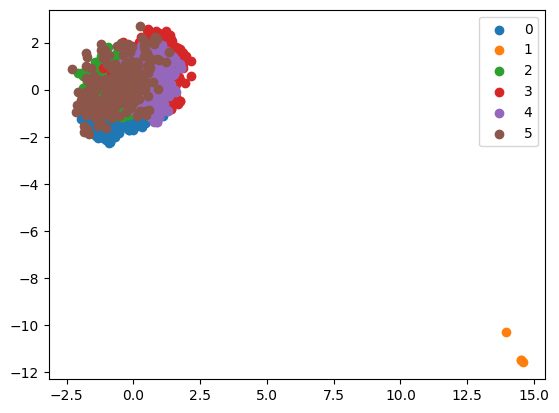

In [71]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(2)
 
#Transform the data
df = pca.fit_transform(X_scaled)
df.shape

#filter rows of original data
filtered_label0 = df[k_labels == 0]
 
u_labels = np.unique(k_labels)
 
#plotting the results:
 
for i in u_labels:
    plt.scatter(df[k_labels == i , 0] , df[k_labels == i , 1] , label = i)
plt.legend()
plt.show()

2. Using the best result, try to interpret (label) the clusters. What do they represent?